In [2]:
import numpy as np

In [3]:
figurita = np.array ([
    [255, 255, 255, 255, 255, 255, 255, 255],
    [255, 0, 1, 1, 1, 1, 0, 255],
    [255, 0, 255, 255, 255, 255, 0, 255],
    [255, 0, 253, 253, 253, 253, 0, 255],
    [255, 0, 254, 253, 253, 254, 0, 255],
    [255, 0, 255, 255, 255, 255, 0, 255],
    [255, 1, 1, 1, 1, 1, 1, 255],
    [255, 255, 255, 255, 255, 255, 255, 255]])


[[[172  47 117 192  67 251 195 103]
  [  9 211  21 242  36  87  70 216]
  [ 88 140  58 193 230  39  87 174]
  [ 88  81 165  25  77  72   9 148]
  [115 208 243 197 254  79 175 192]
  [ 82  99 216 177 243  29 147 147]
  [142 167  32 193   9 185 127  32]
  [ 31 202 244 151 163 254 203 114]]

 [[183  28  34 128 128 164  53 133]
  [ 38 232 244  17  79 132 105  42]
  [186  31 120   1  65 231 169  57]
  [ 35 102 119  11 174  82  91 128]
  [142  99  53 140 121 170  84 203]
  [ 68   6 196  47 127 244 131 204]
  [100 180 232  78 143 148 227 186]
  [ 23 207 141 117  85  48  49  69]]

 [[169 163 192  95 197  94   0 113]
  [178  36 162  48  93 131  98  42]
  [205 112 231 149 201 127   0 138]
  [114  43 186 127  23 187 130 121]
  [ 98  62 163 222 123 195  82 174]
  [227 148 209  50 155  14  41  58]
  [193  36  10  86  43 104  11   2]
  [ 51  80  32 182 128  38  19 174]]]


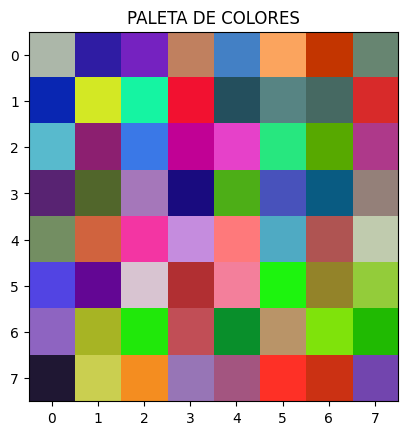

(1, 192)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoide(z):
  return 1.0/(1.0+(np.exp(-z)))

def deri_sig2(x):
  return np.exp(-x)/(1.0+np.exp(-x))**2

delta = 0.7
alpha=0.7
ECM= 3
epocas=20000
ecm_values = []
epoca= 0

np.random.seed(0)
X_r = np.random.randint(0, 256, size=( 8, 8))
X_g = np.random.randint(0, 256, size=(8, 8))
X_b = np.random.randint(0, 256, size=(8, 8))

X_rgb = np.array([X_r,X_g,X_b])
X_rgb = np.transpose(X_rgb, (1, 2, 0))
print(np.array([X_r,X_g,X_b]))
plt.imshow(X_rgb)
plt.title("PALETA DE COLORES")
plt.show()

X_rnormalizado= X_r/255
X_gnormalizado= X_g/255
X_bnormalizado= X_b/255

X_rn= X_rnormalizado.flatten()
X_gn= X_gnormalizado.flatten()
X_bn= X_bnormalizado.flatten()


X_rn = X_rn.reshape(1, -1)
X_gn = X_gn.reshape(1, -1)
X_bn = X_bn.reshape(1, -1)

X_normalizada = np.hstack([X_rn, X_gn, X_bn])
print(X_normalizada.shape)

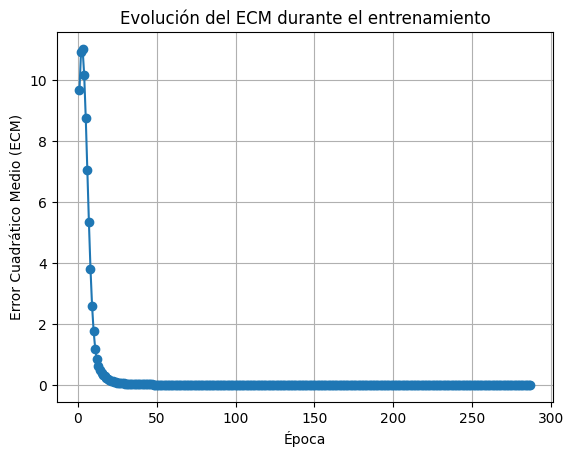

X:  [-1.          0.6745098   0.18431373  0.45882353  0.75294118  0.2627451
  0.98431373  0.76470588  0.40392157  0.03529412  0.82745098  0.08235294
  0.94901961  0.14117647  0.34117647  0.2745098   0.84705882  0.34509804
  0.54901961  0.22745098  0.75686275  0.90196078  0.15294118  0.34117647
  0.68235294  0.34509804  0.31764706  0.64705882  0.09803922  0.30196078
  0.28235294  0.03529412  0.58039216  0.45098039  0.81568627  0.95294118
  0.77254902  0.99607843  0.30980392  0.68627451  0.75294118  0.32156863
  0.38823529  0.84705882  0.69411765  0.95294118  0.11372549  0.57647059
  0.57647059  0.55686275  0.65490196  0.1254902   0.75686275  0.03529412
  0.7254902   0.49803922  0.1254902   0.12156863  0.79215686  0.95686275
  0.59215686  0.63921569  0.99607843  0.79607843  0.44705882  0.71764706
  0.10980392  0.13333333  0.50196078  0.50196078  0.64313725  0.20784314
  0.52156863  0.14901961  0.90980392  0.95686275  0.06666667  0.30980392
  0.51764706  0.41176471  0.16470588  0.72941176

In [ ]:
neurona_entrada =  X_normalizada.shape[1]
neurona_latente = 1
neurona_salida = neurona_entrada

X = np.insert(X_normalizada,0,-1,axis=1)

W_entrada= 2*np.random.rand(X.shape[1],neurona_entrada) -1

W_oculta=2*np.random.rand(neurona_entrada+1,neurona_latente)-1

W_salida= 2*np.random.rand(neurona_latente+1,neurona_salida)-1



W_new_input= np.zeros(W_entrada.shape)
W_old_input= np.zeros(W_entrada.shape)

W_new_hidden= np.zeros(W_oculta.shape)
W_old_hidden= np.zeros(W_oculta.shape)

W_new_output= np.zeros(W_salida.shape)
W_old_output= np.zeros(W_salida.shape)



while(ECM >= 0.001 and epoca<=epocas):
     for j in range (0, X.shape[0]): #evalua casos

#for epoca in range (epocas):

        z_entrada = np.dot(X,W_entrada) #primera capa
        y_entrada = np.insert(sigmoide(z_entrada),0,-1,axis=1) #primera capa

        z_oculta = np.dot(y_entrada,W_oculta)
        y_oculta = np.insert(sigmoide(z_oculta),0,-1,axis=1)

        z_salida =  np.dot(y_oculta,W_salida)
        Yobt = sigmoide(z_salida)



        aux= (X[:, 1:]-Yobt)*deri_sig2(z_salida)
        aux2 = np.dot(aux,W_salida[1:, :].T)*deri_sig2(z_oculta)
        aux3 = np.dot(aux2,W_oculta[1:, :].T)*deri_sig2(z_entrada)

        W_salida = W_salida + delta*np.dot(y_oculta.T,aux)
        W_oculta = W_oculta + delta*np.dot(y_entrada.T,aux2)
        W_entrada = W_entrada + delta*np.dot(X.T,aux3)


#-------------------Actualizacion con Momentum------------------

        W_new_output = W_salida + alpha*(W_salida- W_old_output)+ delta*np.dot(y_oculta.T,aux)
        W_old_output = W_salida
        W_salida = W_new_output

        W_new_hidden = W_oculta + alpha*(W_oculta- W_old_hidden)+ delta*np.dot(y_entrada.T,aux2)
        W_old_hidden = W_oculta
        W_oculta = W_new_hidden

        W_new_input = W_entrada + alpha*(W_entrada-W_old_input)+ delta*np.dot(X.T,aux3)
        W_old_input = W_entrada
        W_entrada = W_new_input

     ECM = (1/2)*np.sum((X[:, 1:]-Yobt)**2)
     ecm_values.append(ECM)  # Almacenar el valor actual de ECM
     epoca = epoca + 1
     print("Epoca: ", epoca)
     print("Y obt de la epoca: ", Yobt)


     z_entrada = np.dot(X,W_entrada) #primera capa
     y_entrada = np.insert(sigmoide(z_entrada),0,-1,axis=1) #primera capa

     z_oculta = np.dot(y_entrada,W_oculta)
     y_oculta = np.insert(sigmoide(z_oculta),0,-1,axis=1)

     z_salida =  np.dot(y_oculta,W_salida)
     Yobt = sigmoide(z_salida)

# Graficar el ECM a lo largo de las épocas
plt.plot(range(1, epoca+1), ecm_values, marker='o')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio (ECM)')
plt.title('Evolución del ECM durante el entrenamiento')
plt.grid(True)
plt.show()
print("X: ", X.flatten())
print("Y obt final: ", np.round(Yobt*255))

In [ ]:
forma_original = (3, 8, 8)
y= np.round(Yobt*255)
# Reorganizar Yobt para que tenga la forma original
Yobt_reshaped = y.reshape(forma_original)
print(Yobt_reshaped)



[[[172.  47. 117. 192.  67. 248. 195. 103.]
  [ 10. 211.  21. 242.  36.  87.  70. 216.]
  [ 88. 140.  58. 193. 230.  39.  87. 174.]
  [ 88.  81. 165.  25.  77.  72.  10. 148.]
  [115. 208. 243. 197. 250.  79. 175. 192.]
  [ 82.  99. 216. 177. 243.  29. 147. 147.]
  [142. 167.  32. 193.  10. 185. 127.  32.]
  [ 31. 202. 245. 151. 163. 250. 203. 114.]]

 [[183.  28.  34. 128. 128. 164.  53. 133.]
  [ 38. 232. 244.  17.  79. 132. 105.  42.]
  [186.  31. 120.   5.  65. 231. 169.  57.]
  [ 35. 102. 119.  11. 174.  82.  91. 128.]
  [142.  99.  53. 140. 121. 170.  84. 203.]
  [ 68.   7. 196.  47. 127. 244. 131. 204.]
  [100. 180. 232.  78. 143. 148. 227. 186.]
  [ 23. 207. 141. 117.  85.  48.  49.  69.]]

 [[169. 163. 192.  95. 197.  94.   5. 113.]
  [178.  36. 162.  48.  93. 131.  98.  42.]
  [205. 112. 231. 149. 201. 127.   5. 138.]
  [114.  43. 186. 127.  23. 187. 130. 121.]
  [ 98.  62. 163. 222. 123. 195.  82. 174.]
  [227. 148. 209.  50. 155.  14.  41.  58.]
  [193.  36.  11.  86.  43. 

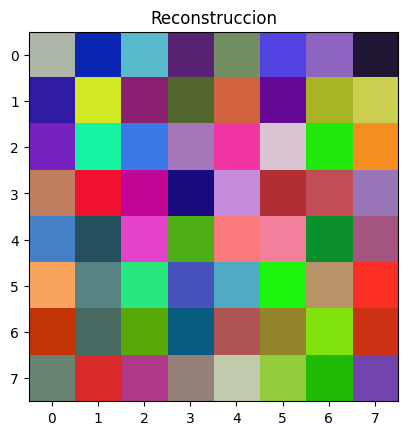

In [ ]:
# Transponer Yobt_reshaped para cambiar el orden de las dimensiones
Yobt_transpuesta = Yobt_reshaped.transpose((2, 1, 0))/ 255.0

# Mostrar la imagen correspondiente a Yobt_transpuesta
plt.imshow(Yobt_transpuesta)
plt.title("Reconstruccion")
plt.show()


Text(0.5, 1.0, 'Reconstruccion')

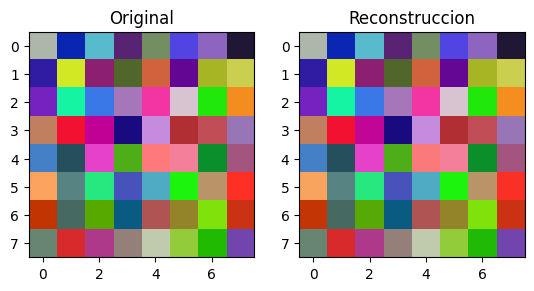

In [ ]:
X_rgb_transpuesta = X_rgb.transpose((1, 0, 2))
plt.subplot(1, 2, 1)  # Primer subplot
plt.imshow(X_rgb_transpuesta)
plt.title("Original")

plt.subplot(1, 2, 2)  # Segundo subplot
plt.imshow(Yobt_transpuesta)
plt.title("Reconstruccion")

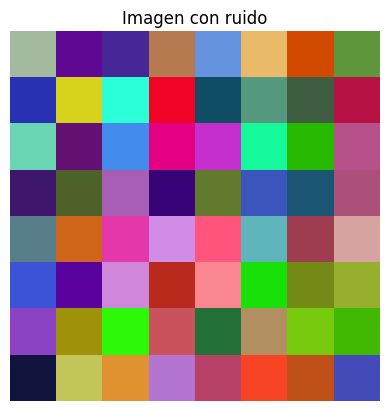

In [ ]:
ruido = np.random.normal(loc=0, scale=20, size=X_rgb.shape)

# Aplicar el ruido a la imagen RGB
X_rgb_con_ruido = X_rgb + ruido

# Asegurar que los valores estén dentro del rango [0, 255]
X_rgb_con_ruido = np.clip(X_rgb_con_ruido, 0, 255)


plt.imshow(X_rgb_con_ruido.astype('uint8'))  # Convertir los valores a enteros sin signo de 8 bits
plt.title('Imagen con ruido')
plt.axis('off')  # Desactivar los ejes
plt.show()


In [ ]:
# Normalizar los valores de la imagen con ruido
X_rgb_con_ruido_normalizado = X_rgb_con_ruido / 255.0

# Reformatear la imagen para que coincida con el formato de entrada del autoencoder
X_rgb_con_ruido_normalizado = X_rgb_con_ruido_normalizado.reshape(1, -1)

prueba = np.insert(X_rgb_con_ruido_normalizado,0,-1,axis=1)

In [ ]:
z_entrada = np.dot(prueba,W_entrada) #primera capa
y_entrada = np.insert(sigmoide(z_entrada),0,-1,axis=1) #primera capa

z_oculta = np.dot(y_entrada,W_oculta)
y_oculta = np.insert(sigmoide(z_oculta),0,-1,axis=1)

z_salida =  np.dot(y_oculta,W_salida)
Yobt_prueba = sigmoide(z_salida)
print("X: ", prueba.flatten())
print("Y obt final: ", np.round(Yobt_prueba*255))



[[[137. 204. 182. 111. 148. 171. 103. 164.]
  [127. 193. 212. 188.  69. 169. 131.  75.]
  [188. 134. 142. 123. 137.  75. 177.  81.]
  [176.  69. 119. 175.  49. 177. 181. 176.]
  [132. 132. 116. 115.  69.  74. 123. 203.]
  [ 76.  74. 189.  91. 106. 138. 124. 108.]
  [118. 190. 184. 145. 196. 211.  64. 114.]
  [ 89.  64.  54. 200. 154. 150. 199. 111.]]

 [[114.  60. 189. 127.  74. 165.  79. 148.]
  [103. 133. 113. 197.  85.  81. 114. 110.]
  [206. 119. 140. 127. 187. 208.  84. 114.]
  [163.  80. 196. 150. 118. 152.  73. 134.]
  [201. 158. 107.  83.  74. 170. 120. 156.]
  [169. 142. 208.  90. 173.  89. 208. 212.]
  [115. 104.  93.  92. 151.  92. 172.  38.]
  [ 78. 122. 176. 132. 163.  78. 100. 133.]]

 [[158.  86. 130. 107.  63. 108. 130.  88.]
  [204.  58. 116.  40.  79. 111. 170.  93.]
  [179. 174.  99. 186. 134.  76. 131.  85.]
  [196. 176.  90. 111. 133. 121. 202. 123.]
  [ 93. 168.  71. 173.  54. 109. 202.  68.]
  [114.  94. 179. 177. 139. 173.  48. 127.]
  [199. 172. 101.  66. 115. 

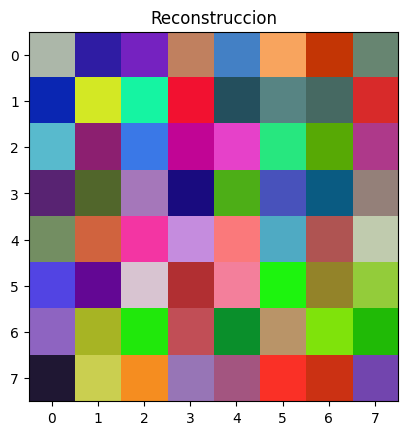

In [ ]:
forma_original = (3, 8, 8)
y_prueba= np.round(Yobt_prueba*255)
# Reorganizar Yobt para que tenga la forma original
Yobt_reshaped_prueba = y_prueba.reshape(forma_original)
print(Yobt_reshaped_prueba)
# Transponer Yobt_reshaped para cambiar el orden de las dimensiones
Yobt_transpuesta_prueba = Yobt_reshaped.transpose((1, 2, 0))/ 255.0

# Mostrar la imagen correspondiente a Yobt_transpuesta
plt.imshow(Yobt_transpuesta_prueba)
plt.title("Reconstruccion")
plt.show()